# Artificial Neural Network Regressor

Notebook version of the ANN model used in the `teste` dashboard pipeline.
It loads the current dataset, applies the same preprocessing, trains the model,
prints the main values, and shows the main plots.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

ROOT = Path.cwd().parents[0] if Path.cwd().name == 'teste' else Path.cwd()
DATASET_PATH = ROOT / 'Dataset-iGov.csv'
CATEGORICAL_COLUMNS = [
    'unidade_organizacional',
    'tipo_servico',
    'canal_utilizado',
    'transparencia',
    'feedback_cidadao',
    'segmentacao_utilizador',
    'area_tematica',
]

print(DATASET_PATH)

c:\Users\Ricardo\Documents\GitHub\AOOP\Dataset-iGov.csv


In [2]:
df = pd.read_csv(DATASET_PATH)
df.head()

,id_registo,data_registo,unidade_organizacional,tipo_servico,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,canal_utilizado,taxa_abandono,erros_tecnicos,transparencia,feedback_cidadao,segmentacao_utilizador,area_tematica,indicador_kpi
0,1,2024-04-12,Direcção De Serviços Financeiros,Telefone,83.02,87.37,36,3.8,368,Presencial,22.41,7,Sim,Processo Complicado,Empresa,Cultura,63.13
1,2,2024-12-14,Departamento De Inovação E Digitalização,Balcão Único,75.53,89.71,29,4.1,349,Email,14.87,1,Sim,Bom Serviço,Funcionário Público,Saúde,63.58
2,3,2024-09-27,Direcção De Recursos Humanos,Chatbot,85.73,75.96,38,3.3,398,Telefone,15.42,5,Não,Processo Complicado,Estudante,Inovação,73.64
3,4,2024-04-16,Departamento De Planeamento Estratégico,Email,78.33,73.82,57,3.4,74,Aplicacao_Movel,15.32,11,Sim,Processo Complicado,Funcionário Público,Digitalização,99.19
4,5,2024-03-12,Direcção De Recursos Humanos,Atendimento Presencial,81.82,70.41,97,4.7,487,Portal,7.47,4,Sim,Serviço Eficiente,Cidadão,Saúde,63.45


In [3]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

X_train = train_df.drop(columns=['indicador_kpi', 'data_registo'])
y_train = train_df['indicador_kpi']
X_test = test_df.drop(columns=['indicador_kpi', 'data_registo'])
y_test = test_df['indicador_kpi']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'encode_categories',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            CATEGORICAL_COLUMNS,
        )
    ],
    remainder='passthrough',
)

ann_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('scaler', MinMaxScaler()),
        (
            'regressor',
            MLPRegressor(
                hidden_layer_sizes=(32, 16),
                activation='relu',
                solver='adam',
                early_stopping=True,
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

ann_model.fit(X_train, y_train)
train_pred = ann_model.predict(X_train)
test_pred = ann_model.predict(X_test)

regressor = ann_model.named_steps['regressor']
encoded_feature_count = regressor.coefs_[0].shape[0]
encoded_feature_count

56

In [4]:
metrics_df = pd.DataFrame(
    {
        'metric': ['MAE', 'MSE', 'RMSE', 'R2'],
        'train': [
            mean_absolute_error(y_train, train_pred),
            mean_squared_error(y_train, train_pred),
            mean_squared_error(y_train, train_pred) ** 0.5,
            r2_score(y_train, train_pred),
        ],
        'test': [
            mean_absolute_error(y_test, test_pred),
            mean_squared_error(y_test, test_pred),
            mean_squared_error(y_test, test_pred) ** 0.5,
            r2_score(y_test, test_pred),
        ],
    }
)

print('Input features after preprocessing:', encoded_feature_count)
print('Hidden layers:', regressor.hidden_layer_sizes)
print('Activation:', regressor.activation)
print('Solver:', regressor.solver)
print('Iterations:', regressor.n_iter_)
print('Final loss:', regressor.loss_)

metrics_df

Input features after preprocessing: 56
Hidden layers: (64, 32)
Activation: relu
Solver: adam
Iterations: 887
Final loss: 1.4199809794967064


,metric,train,test
0,MAE,1.217091,3.404799
1,MSE,2.720674,56.920415
2,RMSE,1.649446,7.544562
3,R2,0.972734,0.412987


In [5]:
prediction_preview = pd.DataFrame(
    {
        'actual': y_test.reset_index(drop=True),
        'predicted': pd.Series(test_pred),
        'error': y_test.reset_index(drop=True) - pd.Series(test_pred),
    }
)
prediction_preview.head(10)

,actual,predicted,error
0,76.79,78.480787,-1.690787
1,72.48,68.660503,3.819497
2,76.94,75.307335,1.632665
3,86.50,83.559339,2.940661
4,75.92,77.074320,-1.154320
5,72.20,73.567685,-1.367685
6,84.57,81.819281,2.750719
7,71.18,71.533532,-0.353532
8,79.82,59.195255,20.624745
9,85.38,90.503608,-5.123608


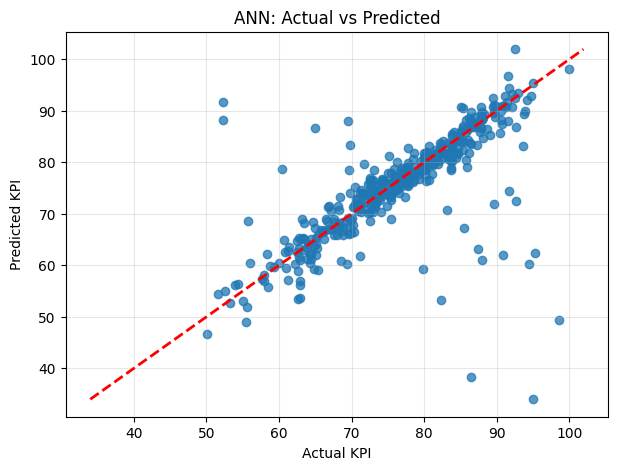

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, test_pred, alpha=0.75)
line_min = min(y_test.min(), test_pred.min())
line_max = max(y_test.max(), test_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=2)
plt.xlabel('Actual KPI')
plt.ylabel('Predicted KPI')
plt.title('ANN: Actual vs Predicted')
plt.grid(alpha=0.3)
plt.show()

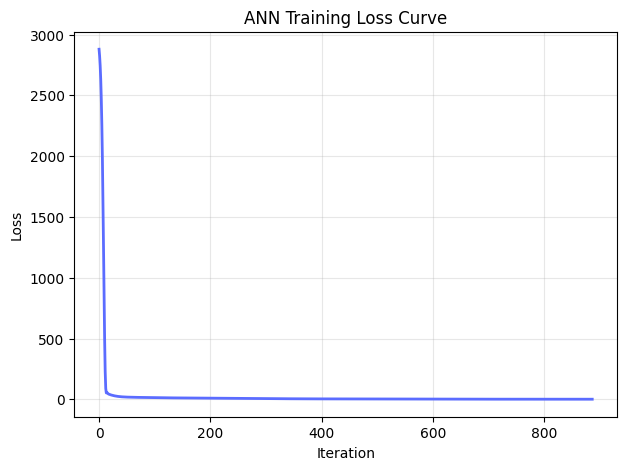

In [7]:
plt.figure(figsize=(7, 5))
plt.plot(regressor.loss_curve_, color='#5b6cff', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('ANN Training Loss Curve')
plt.grid(alpha=0.3)
plt.show()